In [1]:
import pandas as pd
import numpy as np


import os
print(os.listdir("../digit-recognizer/input"))

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms , utils

device = torch.device("cuda"  if torch.cuda.is_available() else "cpu")

print(device)

['test.csv', 'train.csv', '.ipynb_checkpoints', 'sample_submission.csv']
cpu


In [2]:
df_train = pd.read_csv('../digit-recognizer/input/train.csv')
df_test = pd.read_csv("../digit-recognizer/input/test.csv")
print("train size : ",df_train.shape)
print("test size : ",df_test.shape)
df_train.head()

train size :  (42000, 785)
test size :  (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
train_data = df_train.drop('label',axis=1).values

train_mean = train_data.mean()/255
train_std = train_data.std()/255

print('Mean :',train_mean)
print('Std : ',train_std)

Mean : 0.13101533792088266
Std :  0.3085401559245608


In [4]:
mask = np.random.rand(len(df_train)) < 0.8

df_val = df_train[~mask]
df_train = df_train[mask]

print('train size : ',df_train.shape)
print('val size : ',df_val.shape)
print('test size : ',df_test.shape)

df_train.head()

train size :  (33506, 785)
val size :  (8494, 785)
test size :  (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


/var/folders/s7/3cn6dv69701dkpcp4c414khw0000gn/T/ipykernel_62383/1901674312.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.title(str(df_train.iloc[ind][0]))


Text(0.5, 1.0, '3')

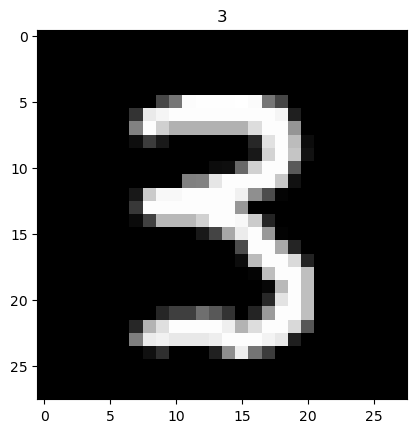

In [5]:
import matplotlib.pyplot as plt
ind = np.random.randint(0,df_train.shape[0]-1)


plt.imshow(df_train.iloc[ind].values[1:].reshape((28,28)),cmap='gray')

plt.title(str(df_train.iloc[ind][0]))
# ind = np.random.randint(0, df_train.shape[0]-1)
# plt.imshow(df_train.iloc[ind].values[1:].reshape((28,28)), cmap='gray')
# plt.title(str(df_train.iloc[ind][0]))

###### CREATE DATASET CLASS FOR PYTORCH

THIS CLASS WILL MAKE OUR DATA COMPATABLE WITH THE DATALOADERS OF PYTORCH WHICH WILL HELP US TO TRAIN OUR MODEL AND TEST IT..

In [6]:
class MNISTDataset(Dataset):
    def __init__(self,df,transform=None):
        self.df =df
        self.transform = transform


    def __len__(self):
        return len(self.df)

    def __getitem__(self,n):
        data = self.df.iloc[n]
        image = data[1:].values.reshape((28,28)).astype(np.uint8)

        label = data[0]
        if self.transform:
            image = self.transform(image)

        return (image,label)

## tranformation datasets and dataloader pipeline for train vll and test data

In [7]:
batch_size = 16
classes = range(10)

train_transform = transforms.Compose(
    [
       transforms.ToPILImage(),
        transforms.RandomAffine(degrees=20,translate=(0.1,0.1),scale=(0.9,1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[train_mean],std=[train_std])
        
])

val_transforms = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[train_mean],std=[train_std])

    ]
)
test_transforms = val_transforms

train_dataset = MNISTDataset(df_train,transform = train_transform)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)

val_dataset = MNISTDataset(df_val,transform = val_transforms)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset,batch_size=batch_size,shuffle=False)

tensor(-0.4246)
tensor(2.8164)
tensor(0.0327)
tensor(1.0364)
8


/var/folders/s7/3cn6dv69701dkpcp4c414khw0000gn/T/ipykernel_62383/3693119522.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = data[0]


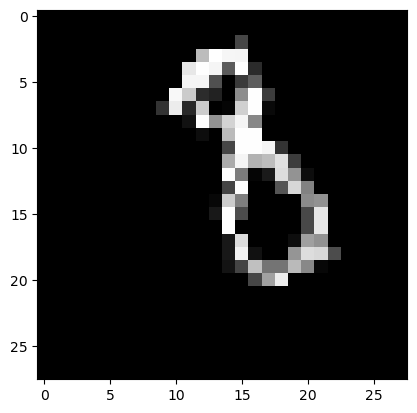

In [8]:
# sanity check for training data
imgs, lbls = next(iter(train_loader))
imgs[7].data.shape
print(imgs.data.min())
print(imgs.data.max())
print(imgs.data.mean())
print(imgs.data.std())
print(classes[lbls[0]])
plt.imshow(imgs[0].data.reshape((28,28)), cmap="gray")

tensor(-0.4246)
tensor(2.8164)
tensor(-0.0168)
tensor(0.9954)
0


/var/folders/s7/3cn6dv69701dkpcp4c414khw0000gn/T/ipykernel_62383/3693119522.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = data[0]


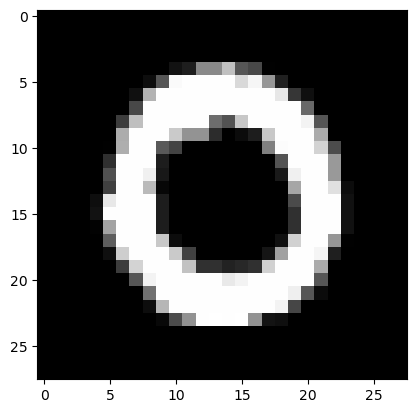

In [9]:
# sanity check for training data
imgs, lbls = next(iter(val_loader))
imgs[7].data.shape
print(imgs.data.min())
print(imgs.data.max())
print(imgs.data.mean())
print(imgs.data.std())
print(classes[lbls[0]])
plt.imshow(imgs[0].data.reshape((28,28)), cmap="gray")

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self):
        super(Model,self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32,32,3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32,32,3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2,2),
            nn.Dropout(0.25)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )
        self.clasifier = nn.Sequential(
            nn.Linear(128,10)
        )

    def forward(self,x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = torch.flatten(x,1)
        x = self.clasifier(x)

        return F.log_softmax(x,dim=1)

In [11]:
model = Model()
model.to(device)
criterion = nn.NLLLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

In [12]:
model

Model(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5):

In [13]:
import time
import copy

epochs =10
train_losses,val_losses =[],[]
train_accu,val_accu = [],[]
start_time = time.time()
early_stop_counter = 10

counter=0
best_val_loss =float('Inf')

for e in range(epochs):
    epoch_start_time = time.time()
    running_loss =0
    accuracy=0
    model.train()
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        log_ps = model(images)

        ps =torch.exp(log_ps)
        top_p, top_class = ps.topk(1, dim=1)
        equals = top_class == labels.view(*top_class.shape)
        accuracy += torch.mean(equals.type(torch.FloatTensor))

        loss = criterion(log_ps,labels)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()


    train_losses.append(running_loss/len(train_loader))
    train_accu.append(accuracy/len(train_loader))
    val_loss =0
    accuracy=0
    model.eval()
    with torch.no_grad():
        for images,labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            log_ps = model(images)
            val_loss += criterion(log_ps,labels)

            ps = torch.exp(log_ps)
            top_p, top_class = ps.topk(1, dim=1)
            equals = top_class == labels.view(*top_class.shape)
            accuracy += torch.mean(equals.type(torch.FloatTensor))
    val_losses.append(val_loss/len(val_loader))
    val_accu.append(accuracy/len(val_loader))

    print("Epoch:{}/{}.. ".format(e+1,epochs),
          "Time: {:.2f}s..".format(time.time()-epoch_start_time),
          "Training Loss: {:.3f}.. ".format(train_losses[-1]),
          "Training Accu: {:.3f}.. ".format(train_accu[-1]),
          "Val Loss: {:.3f}.. ".format(val_losses[-1]),
          "Val Accu: {:.3f}".format(val_accu[-1])
         )



    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        counter=0
        best_model_wts = copy.deepcopy(model.state_dict())
    else:
        counter+=1
        print('Validation loss has not improved since: {:.3f}..'.format(best_val_loss), 'Count: ', str(counter))
        if counter >= early_stop_counter:
            print('Early Stopping Now!!!!')
            model.load_state_dict(best_model_wts)
            break
        
            

/var/folders/s7/3cn6dv69701dkpcp4c414khw0000gn/T/ipykernel_62383/3693119522.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = data[0]


Epoch:1/10..  Time: 140.41s.. Training Loss: 0.873..  Training Accu: 0.714..  Val Loss: 0.085..  Val Accu: 0.974
Epoch:2/10..  Time: 137.96s.. Training Loss: 0.226..  Training Accu: 0.932..  Val Loss: 0.051..  Val Accu: 0.984
Epoch:3/10..  Time: 142.53s.. Training Loss: 0.155..  Training Accu: 0.954..  Val Loss: 0.045..  Val Accu: 0.986
Epoch:4/10..  Time: 138.57s.. Training Loss: 0.122..  Training Accu: 0.962..  Val Loss: 0.035..  Val Accu: 0.989
Epoch:5/10..  Time: 145.41s.. Training Loss: 0.101..  Training Accu: 0.970..  Val Loss: 0.033..  Val Accu: 0.990
Epoch:6/10..  Time: 139.03s.. Training Loss: 0.088..  Training Accu: 0.973..  Val Loss: 0.034..  Val Accu: 0.990
Validation loss has not improved since: 0.033.. Count:  1
Epoch:7/10..  Time: 139.29s.. Training Loss: 0.079..  Training Accu: 0.975..  Val Loss: 0.030..  Val Accu: 0.990
Epoch:8/10..  Time: 138.07s.. Training Loss: 0.073..  Training Accu: 0.977..  Val Loss: 0.027..  Val Accu: 0.992
Epoch:9/10..  Time: 140.01s.. Training

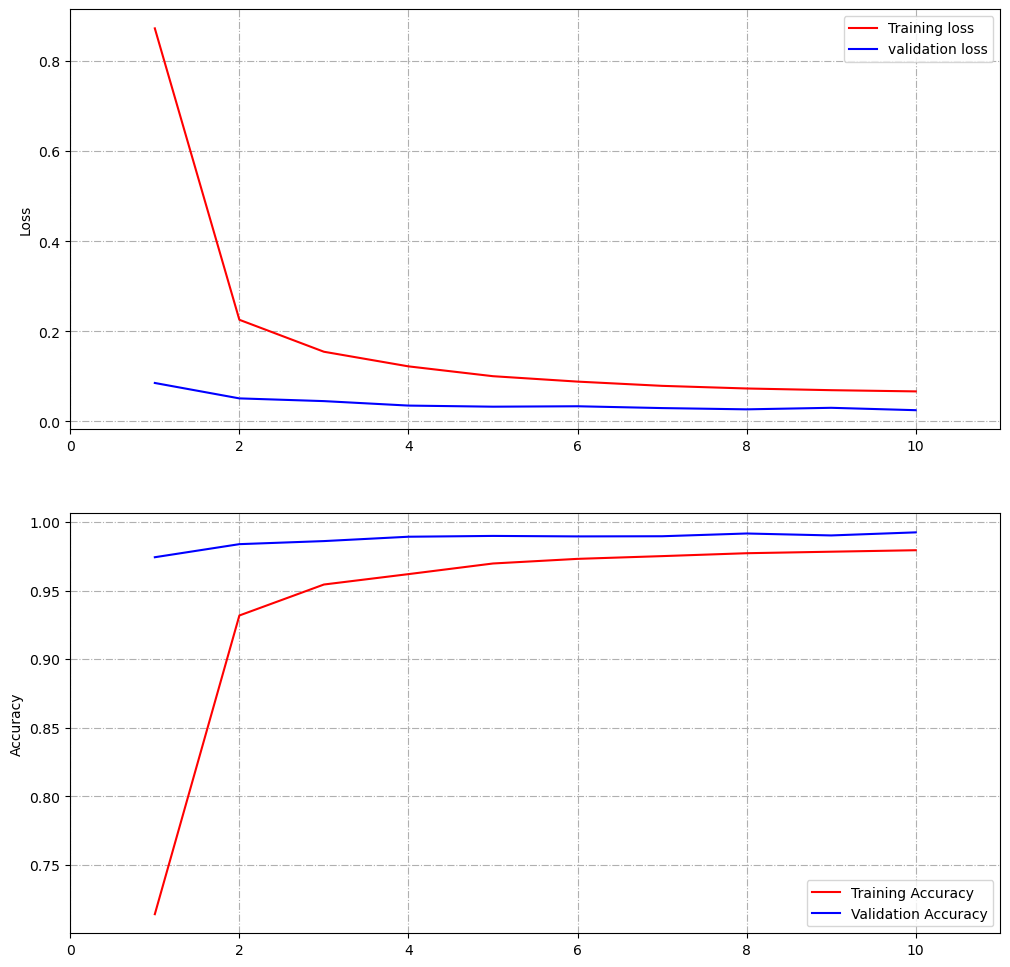

In [17]:
plt.figure(figsize=(12,12))
plt.subplot(2,1,1)
ax = plt.gca()
ax.set_xlim([0,e+2])
plt.ylabel('Loss')
plt.plot(range(1,e+2),train_losses[:e+1],'r',label='Training loss')
plt.plot(range(1,e+2),val_losses[:e+1],'b',label='validation loss')
ax.grid(linestyle='-.')
plt.legend()
plt.subplot(2,1,2)
ax = plt.gca()
ax.set_xlim([0, e+2])
plt.ylabel('Accuracy')
plt.plot(range(1, e + 2), train_accu[:e+1], 'r', label='Training Accuracy')
plt.plot(range(1, e + 2), val_accu[:e+1], 'b', label='Validation Accuracy')
ax.grid(linestyle='-.')
plt.legend()
plt.show()



### PREDICTION

In [22]:
x_test= df_test.values
x_test = x_test.reshape([-1,28,28]).astype(float)
x_test = x_test/255
x_test = (x_test-train_mean)/train_std
print(x_test.min())
print(x_test.max())
print(x_test.mean())
print(x_test.std())

-0.4246297780212323
2.8164394338725467
-0.0007291270898606
0.9992572115903948


In [23]:
x_test = np.expand_dims(x_test,axis=1)
x_test = torch.from_numpy(x_test).float().to(device)

x_test.type()

'torch.FloatTensor'

In [24]:
model.eval()

with torch.inference_mode():

    ps = model(x_test)
    pred = torch.argmax(ps,1)
    print('prediction',pred)

prediction tensor([2, 0, 9,  ..., 3, 9, 2])


In [25]:
df_export = pd.DataFrame(pred.cpu().tolist(),columns=['Label'])
df_export['ImageId'] = df_export.index+1
df_export = df_export[['ImageId','Label']]
df_export.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [26]:
df_export.to_csv('output.csv',index=False)